Results
Heat Flow J = 1.704e+10 W/m^2
Temperature Gradient dT/dx = 7.890e+10 K/m
Thermal Conductivity Coefficient λ = 0.216 W/m·K


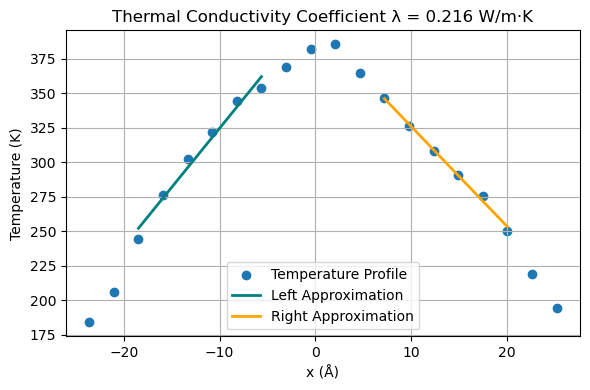

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ============================================================================
# 1. log.lammps
# ============================================================================

def read_lammps_log(filename):
    data_blocks = []
    current_data = []
    headers = None

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if line.startswith("Step") and "f_3" in line:
                headers = line.split()
                current_data = []
                continue

            if headers and line and line[0].isdigit():
                vals = line.split()
                if len(vals) == len(headers):
                    current_data.append(vals)
                continue

            if headers and current_data and (line == "" or not line[0].isdigit()):
                df = pd.DataFrame(current_data, columns=headers).astype(float)
                data_blocks.append(df)
                headers = None

    if not data_blocks:
        raise ValueError("Не найден блок с f_3 в log.lammps")

    return data_blocks[-1]


log = read_lammps_log("../LAMMPS/log.lammps")

# убираем разгон
log = log[log["Step"] > log["Step"].min() + 10000]

# ============================================================================
# 2. Flow
# ============================================================================

slope, _, _, _, _ = linregress(log["Step"], log["f_3"])

dt = 1.0  # fs
Lx = log["Lx"].mean()

A = Lx * Lx  # Å^2

J = slope / (2 * A * dt)

# Converion to SI (kcal/mol)
Na = 6.022e23
kcalmol_to_J = 4184 / Na
A_to_m = 1e-10
fs_to_s = 1e-15

J_SI = J * kcalmol_to_J / (A_to_m**2 * fs_to_s)

# ============================================================================
# 3. temp.profile
# ============================================================================

blocks = []
current = []

with open("../LAMMPS/temp.profile") as f:
    for line in f:
        if line.startswith("#"):
            continue

        parts = line.split()

        # timestep
        if len(parts) == 3:
            if current:
                blocks.append(np.array(current))
                current = []
            continue

        # Data
        if len(parts) >= 4:
            chunk = int(parts[0])
            coord = float(parts[1])
            temp = float(parts[3])
            current.append([chunk, coord, temp])

if current:
    blocks.append(np.array(current))

# ============================================================================
# 4. Profile Averging
# ============================================================================

blocks = blocks[-10:]  # Last Step

coords = blocks[0][:,1]
temps = np.array([b[:,2] for b in blocks])

avg_temp = temps.mean(axis=0)

# Sorting
idx = np.argsort(coords)
coords = coords[idx]
avg_temp = avg_temp[idx]

# ============================================================================
# 5.Temperature Gradient
# ============================================================================

n = len(coords)

left = slice(int(0.1*n), int(0.4*n))
right = slice(int(0.6*n), int(0.9*n))

x_left = coords[left]
T_left = avg_temp[left]

x_right = coords[right]
T_right = avg_temp[right]

res_L = linregress(x_left, T_left)
res_R = linregress(x_right, T_right)

slope_L, intercept_L = res_L.slope, res_L.intercept
slope_R, intercept_R = res_R.slope, res_R.intercept

grad = (abs(slope_L) + abs(slope_R)) / 2  # K/Å
grad_SI = grad / A_to_m  # K/m

# ============================================================================
# 6. Thermal Conductivity
# ============================================================================

kappa = J_SI / grad_SI

# ============================================================================
# 7. Display
# ============================================================================

print("="*60)
print("Results")
print("="*60)
print(f"Heat Flow J = {J_SI:.3e} W/m^2")
print(f"Temperature Gradient dT/dx = {grad_SI:.3e} K/m")
print(f"Thermal Conductivity Coefficient λ = {kappa:.3f} W/m·K")
# ============================================================================
# 8. Graph
# ============================================================================

plt.figure(figsize=(6,4))
plt.scatter(coords, avg_temp, label="Temperature Profile")

plt.plot(x_left, slope_L*x_left + intercept_L, label="Left Approximation", color='teal', linewidth=2)
plt.plot(x_right, slope_R*x_right + intercept_R, label="Right Approximation", color='orange', linewidth=2)

plt.xlabel("x (Å)")
plt.ylabel("Temperature (K)")
plt.title(f"Thermal Conductivity Coefficient λ = {kappa:.3f} W/m·K")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()